Step involve in creating ML model

- Gather raw data
- Data Cleaning 
- Exploratory Data Analysis (EDA)
- Divide data in 2 grp
    -X [input independent data col]
    -Y [output dependent data col]
- Spliting the data in
    - Tranning Set
    - Testing Set
- Use the algo and create ML model
- Evaluation of performance using Evolution Metrics

Steps involved in creating a ML Model
- Gathering data [this data gathered is in its raw state and hence may have redundencies and outliers]
- Data Cleaning / Data Wrangling / Data Pre-processing [clean the raw data into a processed data using Feature Engineering techniques]
- Exploratory Data Analysis (EDA) [clean data is used for fetching the historical patterns from it]
- Divide the data into two groups:
    - X [input independent columns]
    - Y [output dependent column]
- Split the data into two parts:
    - Training Set [majority of the data points - used for making the ML model learn]
    - Testing Set [small set of data points - used for evaluating the performance of the ML model]
- Use the algorithm and create a ML Model
- Evaluation of performance using Evaluation Metrics

In [86]:
#importing dependencies
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score # evalution the performance

In [87]:
import matplotlib.pyplot as plt 
import seaborn as sns

In [20]:
data = pd.read_csv("LoanApprovalPrediction (1).csv")

In [21]:
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [22]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    str    
 1   Gender             598 non-null    str    
 2   Married            598 non-null    str    
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    str    
 5   Self_Employed      598 non-null    str    
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    str    
 12  Loan_Status        598 non-null    str    
dtypes: float64(5), int64(1), str(7)
memory usage: 60.9 KB


In [23]:
data.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [24]:
data.drop('Loan_ID', axis=1,inplace=True)

In [25]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [26]:
from sklearn.impute import SimpleImputer

In [27]:
num_cols = data.select_dtypes(include=np.number).columns
nums_imputer = SimpleImputer(strategy='median')
data[num_cols] = nums_imputer.fit_transform(data[num_cols])

In [28]:
print(num_cols)

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='str')


In [29]:
data.isnull().sum()

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [30]:
from sklearn.preprocessing import LabelEncoder

In [31]:
cat_col = data.select_dtypes(include='object').columns
print(cat_col)

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area',
       'Loan_Status'],
      dtype='str')


C:\Users\261606\AppData\Local\Temp\ipykernel_7860\843183480.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_col = data.select_dtypes(include='object').columns


In [33]:
for col in cat_col:
    le = LabelEncoder() #we initilized the LableEncoder
    data[col]=le.fit_transform(data[col])

In [34]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849.0,0.0,127.0,360.0,1.0,2,1
1,1,1,1.0,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,0,1,3000.0,0.0,66.0,360.0,1.0,2,1
3,1,1,0.0,1,0,2583.0,2358.0,120.0,360.0,1.0,2,1
4,1,0,0.0,0,0,6000.0,0.0,141.0,360.0,1.0,2,1


In [35]:
loan_count = data['Loan_Status'].value_counts()
print(loan_count)

Loan_Status
1    411
0    187
Name: count, dtype: int64


Text(0.5, 1.0, 'Loan Status Distribution')

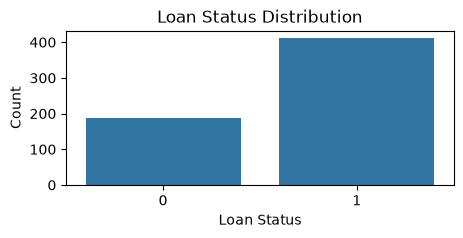

In [37]:
plt.figure(figsize=(5,2))
sns.barplot(x=loan_count.index,y=loan_count.values)
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.title('Loan Status Distribution')

Text(0.5, 1.0, 'Loan Status')

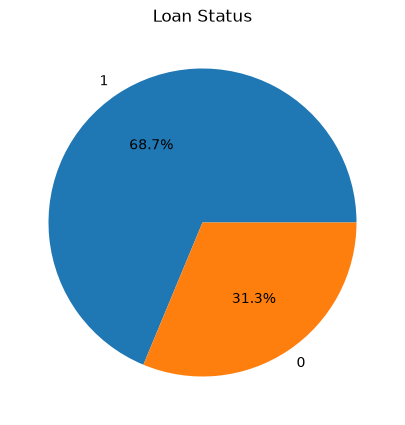

In [48]:
plt.figure(figsize=(5,5))
plt.pie(x = loan_count,labels=loan_count.index, autopct='%1.1f%%')
plt.title('Loan Status') 

In [75]:
x=data.drop(['Loan_Status'],axis=1) #here 'x' stores the input independent columns
y=data['Loan_Status'] #here 'y' stores the output dependent columns

In [76]:
#splitting the data into training and testing data
x_train,x_test,y_train,y_test=train_test_split(x,y,train_size=0.85)
#85% of the data is used for training the model
#15% of the data is used for testing the model

In [77]:
#building the model using Logistic Regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [78]:
model.fit(x_train,y_train)
#using the fit() we are able to train the model in a supervised manner where both the input features as well as the output feature is taken into consideration
     

c:\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

In [79]:
predictions=model.predict(x_test)

In [80]:
#Testing the accuracy of the model
accuracy=accuracy_score(y_test,predictions)
print(accuracy)
     

0.8111111111111111


In [81]:

#Dummy Data
dummy_data=pd.DataFrame({
    "Gender":[1],
    "Married":[1],
    "Dependents":[0],
    "Education":[0],
    "Self_Employed":[0],
    "ApplicantIncome":[500],
    "CoapplicantIncome":[200],
    "LoanAmount":[40000000000],
    "Loan_Amount_Term":[1],
    "Credit_History":[1],
    "Property_Area":[2]
    })

In [82]:
dummy_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,1,1,0,0,0,500,200,40000000000,1,1,2


In [83]:
prediction=model.predict(dummy_data)


In [84]:
print(prediction)

[0]


In [85]:
probability=model.predict_proba(dummy_data)

if prediction[0]==1:
  print("Loan Application Approved")

else:
  print("Loan Application Rejected")

Loan Application Rejected
